# DREAM basics

> "DREAM is SD-CFR-style neural CFR trained from outcome-sampled trajectories,
> made practical by learned baselines, and weighted like LCFR."

This notebook-style version keeps the minimal standalone Leduc setup and
groups the code by the parts used in one training iteration:
- Standard Leduc only
- learned baseline sampling only
- one local learner actor
- one advantage network per player and one learned baseline network

## Setup and helpers

The first code cell loads dependencies, defines the data paths, and adds the
small utility functions used when states move between devices.

In [8]:
import copy
import pickle
import random
import time
from pathlib import Path
import os

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm.auto import tqdm

from PokerRL.game import bet_sets
from PokerRL.game.PokerEnvStateDictEnums import EnvDictIdxs
from PokerRL.game._.tree.PublicTree import PublicTree
from PokerRL.game._.tree._.nodes import PlayerActionNode
from PokerRL.game.games import StandardLeduc
from PokerRL.game.wrappers import FlatLimitPokerEnvBuilder
from PokerRL.rl import rl_util
from PokerRL.rl.base_cls.TrainingProfileBase import TrainingProfileBase
from PokerRL.rl.neural.CardEmbedding import CardEmbedding
from PokerRL.rl.neural.DuelingQNet import DuelingQArgs, DuelingQNet
from PokerRL.rl.neural.LayerNorm import LayerNorm
from PokerRL.rl.neural.MainPokerModuleFLAT import MPMArgsFLAT
from PokerRL.rl.neural.NetWrapperBase import NetWrapperArgsBase as _NetWrapperArgsBase
from PokerRL.rl.neural.NetWrapperBase import NetWrapperBase as _NetWrapperBase


REPO_ROOT = Path(os.getcwd())
print(REPO_ROOT)
DATA_ROOT = REPO_ROOT / "poker_ai_data"

from matplotlib import pyplot as plt
from IPython import display as ipy_display

def clone_state_dict(state_dict, device=None):
    cloned = {}
    for key, value in state_dict.items():
        tensor = value.detach().clone()
        if device is not None:
            tensor = tensor.to(device)
        cloned[key] = tensor
    return cloned


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def render_training_progress(run_name, reports, eval_every):
    clear_output = ipy_display.clear_output
    display = ipy_display.display


    clear_output(wait=True)

    fig, axes = plt.subplots(2, 1, figsize=(11, 8), constrained_layout=True)
    fig.suptitle(f"DREAM on StandardLeduc - {run_name}")

    eval_reports = [r for r in reports if r.get("exploitability") is not None]
    if eval_reports:
        eval_iters = [r["iteration"] + 1 for r in eval_reports]
        exploitability = [r["exploitability"] for r in eval_reports]
        running_best = np.minimum.accumulate(exploitability)

        axes[0].plot(
            eval_iters, exploitability, marker="o", linewidth=2, label="exploitability"
        )
        axes[0].plot(
            eval_iters,
            running_best,
            linestyle="--",
            linewidth=1.5,
            label="best so far",
        )
        axes[0].set_ylabel("mbb/h")
        axes[0].set_title(
            f"Exact best-response evaluation every {eval_every} iterations"
        )
        axes[0].grid(alpha=0.3)
        axes[0].legend()
    else:
        axes[0].set_title("Exploitability will appear after the first evaluation")
        axes[0].set_axis_off()

    iterations = [r["iteration"] + 1 for r in reports]
    states_seen = [r["states_seen"] for r in reports]
    baseline_buf = [r["baseline_buffer_size"] for r in reports]
    adv_buf_mean = [
        float(np.mean(r["adv_buffer_sizes"])) if r["adv_buffer_sizes"] else 0.0
        for r in reports
    ]

    axes[1].plot(iterations, states_seen, linewidth=2, label="states seen")
    axes[1].plot(iterations, adv_buf_mean, linewidth=2, label="mean adv buffer")
    axes[1].plot(iterations, baseline_buf, linewidth=2, label="baseline buffer")
    axes[1].set_xlabel("iteration")
    axes[1].set_ylabel("count")
    axes[1].set_title("Training diagnostics")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    display(fig)
    plt.close(fig)

    latest = reports[-1]
    print(f"Run: {run_name}")
    print(
        f"Latest iteration {latest['iteration'] + 1}: "
        f"states_seen={latest['states_seen']} "
        f"adv_bufs={latest['adv_buffer_sizes']} "
        f"baseline_buf={latest['baseline_buffer_size']}"
    )
    if eval_reports:
        first_eval = eval_reports[0]["exploitability"]
        last_eval = eval_reports[-1]["exploitability"]
        print(
            f"Exploitability: first={first_eval:.4f} last={last_eval:.4f} "
            f"delta={last_eval - first_eval:+.4f}"
        )
    print("Recent evaluations:")
    for report in eval_reports[-5:]:
        print(
            f"  iter {report['iteration'] + 1:>3}: "
            f"exploitability={report['exploitability']:.4f}"
        )

/home/cloexec/Desktop/HSE/RL/RL-HW/DREAM


## Networks and training wrappers

> "Use a neural network to predict infoset-action advantages/regrets."

This section defines the custom baseline encoder and the wrapper classes
that train the advantage and baseline models with PokerRL's helper code.

In [2]:
class MainPokerModuleFLAT_Baseline(nn.Module):
    def __init__(self, env_bldr, device, mpm_args):
        super().__init__()

        self._args = mpm_args
        self._env_bldr = env_bldr
        self._device = device

        self._board_start = self._env_bldr.obs_board_idxs[0]
        self._board_stop = self._board_start + len(self._env_bldr.obs_board_idxs)

        self.dropout = nn.Dropout(p=mpm_args.dropout)
        self.card_emb = CardEmbedding(
            env_bldr=env_bldr, dim=mpm_args.dim, device=device
        )

        if mpm_args.deep:
            self.cards_fc_1 = nn.Linear(self.card_emb.out_size * 2, mpm_args.dim * 3)
            self.cards_fc_2 = nn.Linear(mpm_args.dim * 3, mpm_args.dim * 3)
            self.cards_fc_3 = nn.Linear(mpm_args.dim * 3, mpm_args.dim)

            self.history_1 = nn.Linear(
                self._env_bldr.pub_obs_size - self._env_bldr.obs_size_board,
                mpm_args.dim,
            )
            self.history_2 = nn.Linear(mpm_args.dim, mpm_args.dim)

            self.comb_1 = nn.Linear(2 * mpm_args.dim, mpm_args.dim)
            self.comb_2 = nn.Linear(mpm_args.dim, mpm_args.dim)
        else:
            self.layer_1 = nn.Linear(
                self.card_emb.out_size * 2
                + self._env_bldr.pub_obs_size
                - self._env_bldr.obs_size_board,
                mpm_args.dim,
            )
            self.layer_2 = nn.Linear(mpm_args.dim, mpm_args.dim)
            self.layer_3 = nn.Linear(mpm_args.dim, mpm_args.dim)

        if self._args.normalize:
            self.norm = LayerNorm(mpm_args.dim)

        self.to(device)

    @property
    def output_units(self):
        return self._args.dim

    @property
    def device(self):
        return self._device

    def forward(self, pub_obses, range_idxs):
        if isinstance(pub_obses, list):
            pub_obses = torch.from_numpy(np.array(pub_obses)).to(
                self._device, torch.float32
            )

        hist_o = torch.cat(
            [pub_obses[:, : self._board_start], pub_obses[:, self._board_stop :]],
            dim=-1,
        )

        range_idxs_0 = range_idxs // 10000
        range_idxs_1 = range_idxs % 10000

        card_o_0 = self.card_emb(
            pub_obses=pub_obses,
            range_idxs=torch.where(
                range_idxs_0 == 8888, torch.zeros_like(range_idxs_0), range_idxs_0
            ),
        )
        card_o_0 = torch.where(
            range_idxs_0.unsqueeze(1).expand_as(card_o_0) == 8888,
            torch.full_like(card_o_0, fill_value=-1),
            card_o_0,
        )

        card_o_1 = self.card_emb(
            pub_obses=pub_obses,
            range_idxs=torch.where(
                range_idxs_1 == 8888, torch.zeros_like(range_idxs_1), range_idxs_1
            ),
        )
        card_o_1 = torch.where(
            range_idxs_1.unsqueeze(1).expand_as(card_o_1) == 8888,
            torch.full_like(card_o_1, fill_value=-1),
            card_o_1,
        )
        card_o = torch.cat([card_o_0, card_o_1], dim=-1)

        if self._args.dropout > 0:
            activate = lambda x: self.dropout(F.relu(x))
        else:
            activate = lambda x: F.relu(x)

        if self._args.deep:
            card_o = activate(self.cards_fc_1(card_o))
            card_o = activate(self.cards_fc_2(card_o) + card_o)
            card_o = activate(self.cards_fc_3(card_o))

            hist_o = activate(self.history_1(hist_o))
            hist_o = activate(self.history_2(hist_o) + hist_o)

            y = activate(self.comb_1(torch.cat([card_o, hist_o], dim=-1)))
            y = activate(self.comb_2(y) + y)
        else:
            y = torch.cat([hist_o, card_o], dim=-1)
            y = activate(self.layer_1(y))
            y = activate(self.layer_2(y) + y)
            y = activate(self.layer_3(y) + y)

        if self._args.normalize:
            y = self.norm(y)

        return y


class MPMArgsFLAT_Baseline:
    def __init__(self, deep=True, dim=64, dropout=0.0, normalize=True):
        self.deep = deep
        self.dim = dim
        self.dropout = dropout
        self.normalize = normalize

    def get_mpm_cls(self):
        return MainPokerModuleFLAT_Baseline


class AdvWrapper(_NetWrapperBase):
    def __init__(self, env_bldr, adv_training_args, owner, device):
        super().__init__(
            net=DuelingQNet(
                env_bldr=env_bldr, q_args=adv_training_args.adv_net_args, device=device
            ),
            env_bldr=env_bldr,
            args=adv_training_args,
            owner=owner,
            device=device,
        )

    def _mini_batch_loop(self, buffer, grad_mngr):
        batch = buffer.sample(device=self.device, batch_size=self._args.batch_size)
        (
            batch_pub_obs,
            batch_range_idxs,
            batch_legal_action_masks,
            batch_adv,
            batch_loss_weight,
        ) = batch

        adv_pred = self._net(
            pub_obses=batch_pub_obs,
            range_idxs=batch_range_idxs,
            legal_action_masks=batch_legal_action_masks,
        )

        grad_mngr.backprop(
            pred=adv_pred,
            target=batch_adv,
            loss_weights=batch_loss_weight.unsqueeze(-1).expand_as(batch_adv),
        )


class AdvTrainingArgs(_NetWrapperArgsBase):
    def __init__(
        self,
        adv_net_args,
        n_batches_adv_training=200,
        batch_size=512,
        optim_str="adam",
        loss_str="weighted_mse",
        lr=0.001,
        grad_norm_clipping=1.0,
        device_training="cpu",
        max_buffer_size=200000,
        init_adv_model="random",
    ):
        super().__init__(
            batch_size=batch_size,
            optim_str=optim_str,
            loss_str=loss_str,
            lr=lr,
            grad_norm_clipping=grad_norm_clipping,
            device_training=device_training,
        )
        self.adv_net_args = adv_net_args
        self.n_batches_adv_training = n_batches_adv_training
        self.max_buffer_size = int(max_buffer_size)
        self.init_adv_model = init_adv_model


class BaselineWrapper(_NetWrapperBase):
    def __init__(self, env_bldr, baseline_args):
        super().__init__(
            net=DuelingQNet(
                env_bldr=env_bldr,
                q_args=baseline_args.q_net_args,
                device=baseline_args.device_training,
            ),
            owner=None,
            env_bldr=env_bldr,
            args=baseline_args,
            device=baseline_args.device_training,
        )

        self._batch_arranged = torch.arange(
            self._args.batch_size, dtype=torch.long, device=self.device
        )
        self._minus_e20 = torch.full(
            (self._args.batch_size, self._env_bldr.N_ACTIONS),
            fill_value=-10e20,
            device=self.device,
            dtype=torch.float32,
            requires_grad=False,
        )

    def get_b(self, pub_obses, range_idxs, legal_actions_lists, to_np=False):
        with torch.no_grad():
            range_idxs = torch.tensor(range_idxs, dtype=torch.long, device=self.device)
            masks = rl_util.batch_get_legal_action_mask_torch(
                n_actions=self._env_bldr.N_ACTIONS,
                legal_actions_lists=legal_actions_lists,
                device=self.device,
                dtype=torch.float32,
            )
            self.eval()
            q_values = self._net(
                pub_obses=pub_obses, range_idxs=range_idxs, legal_action_masks=masks
            )
            q_values *= masks
            return q_values.cpu().numpy() if to_np else q_values

    def _mini_batch_loop(self, buffer, grad_mngr):
        batch = buffer.sample(device=self.device, batch_size=self._args.batch_size)
        (
            batch_pub_obs_t,
            batch_range_idx,
            batch_legal_action_mask_t,
            batch_a_t,
            batch_r_t,
            batch_pub_obs_tp1,
            batch_legal_action_mask_tp1,
            batch_done,
            batch_strat_tp1,
        ) = batch

        q_t = self._net(
            pub_obses=batch_pub_obs_t,
            range_idxs=batch_range_idx,
            legal_action_masks=batch_legal_action_mask_t.to(torch.float32),
        )
        q_tp1 = self._net(
            pub_obses=batch_pub_obs_tp1,
            range_idxs=batch_range_idx,
            legal_action_masks=batch_legal_action_mask_tp1.to(torch.float32),
        ).detach()

        q_t_of_a = q_t[self._batch_arranged, batch_a_t]
        q_tp1 = torch.where(batch_legal_action_mask_tp1, q_tp1, self._minus_e20)
        q_tp1_of_atp1 = (q_tp1 * batch_strat_tp1).sum(-1)
        q_tp1_of_atp1 *= 1.0 - batch_done
        target = batch_r_t + q_tp1_of_atp1

        grad_mngr.backprop(pred=q_t_of_a, target=target)


class BaselineArgs(_NetWrapperArgsBase):
    def __init__(
        self,
        q_net_args,
        max_buffer_size=200000,
        n_batches_per_iter_baseline=100,
        batch_size=512,
        optim_str="adam",
        loss_str="mse",
        lr=0.001,
        grad_norm_clipping=1.0,
        device_training="cpu",
    ):
        super().__init__(
            batch_size=batch_size,
            optim_str=optim_str,
            loss_str=loss_str,
            lr=lr,
            grad_norm_clipping=grad_norm_clipping,
            device_training=device_training,
        )
        self.q_net_args = q_net_args
        self.max_buffer_size = int(max_buffer_size)
        self.n_batches_per_iter_baseline = n_batches_per_iter_baseline

## Replay buffers

> "DREAM explicitly uses Linear CFR weighting."

`AdvReservoirBuffer` stores sampled regrets with iteration weights, while
`CrazyBaselineQCircularBuffer` keeps one-step transitions for the learned
baseline.

In [3]:
class ReservoirBufferBase:
    def __init__(self, owner, max_size, env_bldr, nn_type, iter_weighting_exponent):
        self._owner = owner
        self._env_bldr = env_bldr
        self._max_size = max_size
        self._nn_type = nn_type
        self._iter_weighting_exponent = iter_weighting_exponent
        self.device = torch.device("cpu")

        self.size = 0
        self.n_entries_seen = 0
        self._last_iteration_seen = None

        if nn_type == "feedforward":
            self._pub_obs_buffer = torch.zeros(
                (max_size, self._env_bldr.pub_obs_size), dtype=torch.float32
            )
        else:
            raise ValueError(nn_type)

        self._range_idx_buffer = torch.zeros((max_size,), dtype=torch.long)
        self._legal_action_mask_buffer = torch.zeros(
            (max_size, env_bldr.N_ACTIONS), dtype=torch.float32
        )
        self._iteration_buffer = torch.zeros((max_size,), dtype=torch.float32)

    def _should_add(self):
        return np.random.random() < (float(self._max_size) / float(self.n_entries_seen))

    def _random_idx(self):
        return np.random.randint(low=0, high=self._max_size)


class AdvReservoirBuffer(ReservoirBufferBase):
    def __init__(self, owner, nn_type, max_size, env_bldr, iter_weighting_exponent):
        super().__init__(owner, max_size, env_bldr, nn_type, iter_weighting_exponent)
        self._adv_buffer = torch.zeros(
            (max_size, env_bldr.N_ACTIONS), dtype=torch.float32
        )

    def add(self, pub_obs, range_idx, legal_action_mask, adv, iteration):
        idx = (
            self.size
            if self.size < self._max_size
            else self._random_idx()
            if self._should_add()
            else None
        )
        self.n_entries_seen += 1
        if idx is None:
            return

        self._pub_obs_buffer[idx] = torch.from_numpy(pub_obs)
        self._range_idx_buffer[idx] = range_idx
        self._legal_action_mask_buffer[idx] = legal_action_mask.cpu()
        self._adv_buffer[idx] = adv.cpu()
        self._iteration_buffer[idx] = float(iteration) ** self._iter_weighting_exponent
        self._last_iteration_seen = iteration
        if self.size < self._max_size:
            self.size += 1

    def sample(self, batch_size, device):
        indices = torch.randint(0, self.size, (batch_size,), dtype=torch.long)
        return (
            self._pub_obs_buffer[indices].to(device),
            self._range_idx_buffer[indices].to(device),
            self._legal_action_mask_buffer[indices].to(device),
            self._adv_buffer[indices].to(device),
            self._iteration_buffer[indices].to(device) / self._last_iteration_seen,
        )


class CrazyBaselineQCircularBuffer:
    def __init__(self, owner, max_size, env_bldr, nn_type):
        self._owner = owner
        self._max_size = int(max_size)
        self._env_bldr = env_bldr
        self._nn_type = nn_type
        self.device = torch.device("cpu")
        self.reset()

    def add(
        self,
        pub_obs,
        range_idx_crazy_embedded,
        legal_action_mask,
        r,
        a,
        done,
        legal_action_mask_tp1,
        pub_obs_tp1,
        strat_tp1,
    ):
        self._pub_obs_buffer[self._top] = torch.from_numpy(pub_obs)
        self._pub_obs_buffer_tp1[self._top] = torch.from_numpy(pub_obs_tp1)
        self._range_idx_buffer[self._top] = range_idx_crazy_embedded
        self._legal_action_mask_buffer[self._top] = legal_action_mask.cpu()
        self._legal_action_mask_buffer_tp1[self._top] = legal_action_mask_tp1.cpu()
        self._r_buffer[self._top] = r
        self._a_buffer[self._top] = a
        self._done[self._top] = float(done)
        self._strat_tp1_buffer[self._top] = strat_tp1.cpu()

        if self.size < self._max_size:
            self.size += 1
        self._top = (self._top + 1) % self._max_size

    def sample(self, batch_size, device):
        indices = torch.randint(0, self.size, (batch_size,), dtype=torch.long)
        return (
            self._pub_obs_buffer[indices].to(device),
            self._range_idx_buffer[indices].to(device),
            self._legal_action_mask_buffer[indices].to(device),
            self._a_buffer[indices].to(device),
            self._r_buffer[indices].to(device),
            self._pub_obs_buffer_tp1[indices].to(device),
            self._legal_action_mask_buffer_tp1[indices].to(device),
            self._done[indices].to(device),
            self._strat_tp1_buffer[indices].to(device),
        )

    def reset(self):
        self._top = 0
        self.size = 0
        self._pub_obs_buffer = torch.zeros(
            (self._max_size, self._env_bldr.pub_obs_size), dtype=torch.float32
        )
        self._pub_obs_buffer_tp1 = torch.zeros(
            (self._max_size, self._env_bldr.pub_obs_size), dtype=torch.float32
        )
        self._range_idx_buffer = torch.zeros((self._max_size,), dtype=torch.long)
        self._legal_action_mask_buffer = torch.zeros(
            (self._max_size, self._env_bldr.N_ACTIONS), dtype=torch.float32
        )
        self._legal_action_mask_buffer_tp1 = torch.zeros(
            (self._max_size, self._env_bldr.N_ACTIONS), dtype=torch.uint8
        )
        self._a_buffer = torch.zeros((self._max_size,), dtype=torch.long)
        self._r_buffer = torch.zeros((self._max_size,), dtype=torch.float32)
        self._done = torch.zeros((self._max_size,), dtype=torch.float32)
        self._strat_tp1_buffer = torch.zeros(
            (self._max_size, self._env_bldr.N_ACTIONS), dtype=torch.float32
        )

## Outcome-sampling traversal

> "DREAM changes the sampling regime from external sampling to outcome
> sampling"

`LearnedBaselineSampler` follows a single sampled trajectory, applies the
traverser's exploration policy, and turns the sampled return into
baseline-adjusted regret targets.

In [4]:
class SamplerBase:
    def __init__(self, env_bldr, adv_buffers):
        self._env_bldr = env_bldr
        self._adv_buffers = adv_buffers
        self._env_wrapper = self._env_bldr.get_new_wrapper(is_evaluating=False)
        self.total_node_count_traversed = 0

    def generate(self, n_traversals, traverser, iteration_strats, cfr_iter):
        self.total_node_count_traversed = 0
        for _ in range(n_traversals):
            self._env_wrapper.reset()
            self._recursive_traversal(
                start_state_dict=self._env_wrapper.state_dict(),
                traverser=traverser,
                trav_depth=0,
                plyrs_range_idxs=[
                    self._env_wrapper.env.get_range_idx(p_id=p_id)
                    for p_id in range(self._env_bldr.N_SEATS)
                ],
                sample_reach=1.0,
                iteration_strats=iteration_strats,
                cfr_iter=cfr_iter,
            )

    def _traverser_act(
        self,
        start_state_dict,
        traverser,
        trav_depth,
        plyrs_range_idxs,
        iteration_strats,
        sample_reach,
        cfr_iter,
    ):
        raise NotImplementedError

    def _any_non_traverser_act(
        self,
        start_state_dict,
        traverser,
        plyrs_range_idxs,
        trav_depth,
        iteration_strats,
        sample_reach,
        cfr_iter,
    ):
        raise NotImplementedError

    def _recursive_traversal(
        self,
        start_state_dict,
        traverser,
        trav_depth,
        plyrs_range_idxs,
        iteration_strats,
        cfr_iter,
        sample_reach,
    ):
        if start_state_dict["base"]["env"][EnvDictIdxs.current_player] == traverser:
            return self._traverser_act(
                start_state_dict,
                traverser,
                trav_depth,
                plyrs_range_idxs,
                iteration_strats,
                sample_reach,
                cfr_iter,
            )

        return self._any_non_traverser_act(
            start_state_dict,
            traverser,
            plyrs_range_idxs,
            trav_depth,
            iteration_strats,
            sample_reach,
            cfr_iter,
        )


def _crazy_embed(plyrs_range_idxs):
    return plyrs_range_idxs[0] * 10000 + plyrs_range_idxs[1]


class LearnedBaselineSampler(SamplerBase):
    def __init__(self, env_bldr, adv_buffers, baseline_net, baseline_buf, eps=0.5):
        super().__init__(env_bldr=env_bldr, adv_buffers=adv_buffers)
        self._baseline_net = baseline_net
        self._baseline_buf = baseline_buf
        self._eps = eps

    def _traverser_act(
        self,
        start_state_dict,
        traverser,
        trav_depth,
        plyrs_range_idxs,
        iteration_strats,
        sample_reach,
        cfr_iter,
    ):
        self.total_node_count_traversed += 1
        self._env_wrapper.load_state_dict(start_state_dict)

        legal_actions_list = self._env_wrapper.env.get_legal_actions()
        legal_action_mask = rl_util.get_legal_action_mask_torch(
            n_actions=self._env_bldr.N_ACTIONS,
            legal_actions_list=legal_actions_list,
            device=self._adv_buffers[traverser].device,
            dtype=torch.float32,
        )
        pub_obs_t = self._env_wrapper.get_current_obs()
        traverser_range_idx = plyrs_range_idxs[traverser]

        strat_i = iteration_strats[traverser].get_a_probs(
            pub_obses=[pub_obs_t],
            range_idxs=[traverser_range_idx],
            legal_actions_lists=[legal_actions_list],
            to_np=False,
        )[0]

        n_legal_actions = len(legal_actions_list)
        sample_strat = (1 - self._eps) * strat_i + self._eps * (
            legal_action_mask / n_legal_actions
        )
        action = torch.multinomial(sample_strat, num_samples=1).item()

        pub_obs_tp1, rew_for_all, done, _ = self._env_wrapper.step(action)
        legal_action_mask_tp1 = rl_util.get_legal_action_mask_torch(
            n_actions=self._env_bldr.N_ACTIONS,
            legal_actions_list=self._env_wrapper.env.get_legal_actions(),
            device=self._adv_buffers[traverser].device,
            dtype=torch.float32,
        )

        if done:
            strat_tp1 = torch.zeros_like(strat_i)
            u_bootstrap = rew_for_all[traverser]
        else:
            u_bootstrap, strat_tp1 = self._recursive_traversal(
                start_state_dict=self._env_wrapper.state_dict(),
                traverser=traverser,
                trav_depth=trav_depth + 1,
                plyrs_range_idxs=plyrs_range_idxs,
                iteration_strats=iteration_strats,
                cfr_iter=cfr_iter,
                sample_reach=sample_reach * sample_strat[action] * n_legal_actions,
            )

        utility = self._get_utility(
            traverser=traverser,
            u_bootstrap=u_bootstrap,
            range_idx_crazy_embedded=_crazy_embed(plyrs_range_idxs),
            pub_obs=pub_obs_t,
            legal_actions_list=legal_actions_list,
            legal_action_mask=legal_action_mask,
            action=action,
            sample_strat=sample_strat,
        )

        aprx_imm_reg = torch.full(
            size=(self._env_bldr.N_ACTIONS,),
            fill_value=-(utility * strat_i).sum(),
            dtype=torch.float32,
            device=self._adv_buffers[traverser].device,
        )
        aprx_imm_reg += utility
        aprx_imm_reg *= legal_action_mask

        self._adv_buffers[traverser].add(
            pub_obs=pub_obs_t,
            range_idx=traverser_range_idx,
            legal_action_mask=legal_action_mask,
            adv=aprx_imm_reg,
            iteration=(cfr_iter + 1) / sample_reach,
        )

        self._baseline_buf.add(
            pub_obs=pub_obs_t,
            range_idx_crazy_embedded=_crazy_embed(plyrs_range_idxs),
            legal_action_mask=legal_action_mask,
            r=rew_for_all[0],
            a=action,
            done=done,
            pub_obs_tp1=pub_obs_tp1,
            strat_tp1=strat_tp1,
            legal_action_mask_tp1=legal_action_mask_tp1,
        )

        return (utility * strat_i).sum(), strat_i

    def _any_non_traverser_act(
        self,
        start_state_dict,
        traverser,
        plyrs_range_idxs,
        trav_depth,
        iteration_strats,
        sample_reach,
        cfr_iter,
    ):
        self.total_node_count_traversed += 1
        self._env_wrapper.load_state_dict(start_state_dict)
        p_id_acting = self._env_wrapper.env.current_player.seat_id

        current_pub_obs = self._env_wrapper.get_current_obs()
        range_idx = plyrs_range_idxs[p_id_acting]
        legal_actions_list = self._env_wrapper.env.get_legal_actions()
        legal_action_mask = rl_util.get_legal_action_mask_torch(
            n_actions=self._env_bldr.N_ACTIONS,
            legal_actions_list=legal_actions_list,
            device=self._adv_buffers[traverser].device,
            dtype=torch.float32,
        )

        strat_opp = iteration_strats[p_id_acting].get_a_probs(
            pub_obses=[current_pub_obs],
            range_idxs=[range_idx],
            legal_actions_lists=[legal_actions_list],
            to_np=False,
        )[0]

        action = torch.multinomial(strat_opp, num_samples=1).item()
        pub_obs_tp1, rew_for_all, done, _ = self._env_wrapper.step(action)
        legal_action_mask_tp1 = rl_util.get_legal_action_mask_torch(
            n_actions=self._env_bldr.N_ACTIONS,
            legal_actions_list=self._env_wrapper.env.get_legal_actions(),
            device=self._adv_buffers[traverser].device,
            dtype=torch.float32,
        )

        if done:
            strat_tp1 = torch.zeros_like(strat_opp)
            self.total_node_count_traversed += 1
            u_bootstrap = rew_for_all[traverser]
        else:
            u_bootstrap, strat_tp1 = self._recursive_traversal(
                start_state_dict=self._env_wrapper.state_dict(),
                traverser=traverser,
                trav_depth=trav_depth + 1,
                plyrs_range_idxs=plyrs_range_idxs,
                iteration_strats=iteration_strats,
                cfr_iter=cfr_iter,
                sample_reach=sample_reach,
            )

        utility = self._get_utility(
            traverser=traverser,
            u_bootstrap=u_bootstrap,
            pub_obs=current_pub_obs,
            range_idx_crazy_embedded=_crazy_embed(plyrs_range_idxs),
            legal_actions_list=legal_actions_list,
            legal_action_mask=legal_action_mask,
            action=action,
            sample_strat=strat_opp,
        )

        self._baseline_buf.add(
            pub_obs=current_pub_obs,
            range_idx_crazy_embedded=_crazy_embed(plyrs_range_idxs),
            legal_action_mask=legal_action_mask,
            r=rew_for_all[0],
            a=action,
            done=done,
            pub_obs_tp1=pub_obs_tp1,
            strat_tp1=strat_tp1,
            legal_action_mask_tp1=legal_action_mask_tp1,
        )

        return (utility * strat_opp).sum(), strat_opp

    def _get_utility(
        self,
        traverser,
        pub_obs,
        range_idx_crazy_embedded,
        legal_actions_list,
        legal_action_mask,
        u_bootstrap,
        action,
        sample_strat,
    ):
        baselines = self._baseline_net.get_b(
            pub_obses=[pub_obs],
            range_idxs=[range_idx_crazy_embedded],
            legal_actions_lists=[legal_actions_list],
            to_np=False,
        )[0] * (1 if traverser == 0 else -1)

        utility = baselines * legal_action_mask
        utility[action] += (u_bootstrap - utility[action]) / sample_strat[action]
        return utility

## Strategy reconstruction and profile

> "Policies are still produced by regret matching."

`IterationStrategy` rebuilds per-iteration policies from stored advantage
networks, and `TrainingProfile` keeps the minimal Standard Leduc setup.

In [5]:
class IterationStrategy:
    def __init__(self, t_prof, owner, env_bldr, device, cfr_iter):
        self._t_prof = t_prof
        self._owner = owner
        self._env_bldr = env_bldr
        self._device = torch.device(device)
        self._iteration = cfr_iter
        self._adv_net = None

    @property
    def owner(self):
        return self._owner

    @property
    def iteration(self):
        return self._iteration

    def load_net_state_dict(self, state_dict):
        if state_dict is None:
            self._adv_net = None
            return

        self._adv_net = DuelingQNet(
            q_args=self._t_prof.module_args["adv_training"].adv_net_args,
            env_bldr=self._env_bldr,
            device=self._device,
        )
        self._adv_net.load_state_dict(clone_state_dict(state_dict, device=self._device))
        self._adv_net.eval()
        for param in self._adv_net.parameters():
            param.requires_grad = False

    def get_a_probs(self, pub_obses, range_idxs, legal_actions_lists, to_np=True):
        legal_action_masks = rl_util.batch_get_legal_action_mask_torch(
            n_actions=self._env_bldr.N_ACTIONS,
            legal_actions_lists=legal_actions_lists,
            device=self._device,
            dtype=torch.float32,
        )

        if self._iteration == 0 or self._adv_net is None:
            strategy = legal_action_masks / legal_action_masks.sum(-1, keepdim=True)
            return strategy.cpu().numpy() if to_np else strategy

        with torch.no_grad():
            range_idxs = torch.tensor(range_idxs, dtype=torch.long, device=self._device)
            advantages = self._adv_net(
                pub_obses=pub_obses,
                range_idxs=range_idxs,
                legal_action_masks=legal_action_masks,
            )

            relu_advantages = F.relu(advantages, inplace=False)
            sum_pos_adv = relu_advantages.sum(1, keepdim=True).expand_as(
                relu_advantages
            )

            best_legal = torch.zeros_like(advantages)
            best_actions = torch.argmax(
                torch.where(
                    legal_action_masks.byte(),
                    advantages,
                    torch.full_like(advantages, fill_value=-10e20),
                ),
                dim=1,
            )
            best_legal[
                torch.arange(len(range_idxs), device=self._device), best_actions
            ] = 1

            strategy = torch.where(
                sum_pos_adv > 0, relu_advantages / sum_pos_adv, best_legal
            )
            return strategy.cpu().numpy() if to_np else strategy

    def get_a_probs_for_each_hand_in_list(
        self, pub_obs, range_idxs, legal_actions_list
    ):
        with torch.no_grad():
            range_idxs_tensor = torch.as_tensor(
                range_idxs, dtype=torch.long, device=self._device
            )
            n_hands = range_idxs_tensor.numel()

            if self._adv_net is None:
                uniform_even_legal = torch.zeros(
                    (self._env_bldr.N_ACTIONS,),
                    dtype=torch.float32,
                    device=self._device,
                )
                uniform_even_legal[legal_actions_list] = 1.0 / len(legal_actions_list)
                return (
                    uniform_even_legal.unsqueeze(0)
                    .expand(n_hands, self._env_bldr.N_ACTIONS)
                    .cpu()
                    .numpy()
                )

            legal_action_mask = rl_util.get_legal_action_mask_torch(
                n_actions=self._env_bldr.N_ACTIONS,
                legal_actions_list=legal_actions_list,
                device=self._device,
                dtype=torch.float32,
            )
            legal_action_masks = legal_action_mask.unsqueeze(0).expand(n_hands, -1)

            advantages = self._adv_net(
                pub_obses=[pub_obs] * n_hands,
                range_idxs=range_idxs_tensor,
                legal_action_masks=legal_action_masks,
            )

            relu_advantages = F.relu(advantages, inplace=False)
            sum_pos_adv = relu_advantages.sum(1, keepdim=True).expand_as(
                relu_advantages
            )

            best_legal = torch.zeros(
                (n_hands, self._env_bldr.N_ACTIONS),
                dtype=torch.float32,
                device=self._device,
            )
            best_actions = torch.argmax(
                torch.where(
                    legal_action_masks.bool(),
                    advantages,
                    torch.full_like(advantages, fill_value=-10e20),
                ),
                dim=1,
            )
            best_legal[torch.arange(n_hands, device=self._device), best_actions] = 1.0

            strategy = torch.where(
                sum_pos_adv > 0, relu_advantages / sum_pos_adv, best_legal
            )
            return strategy.cpu().numpy()


class StrategyBuffer:
    def __init__(self, t_prof, owner, env_bldr, device):
        self._t_prof = t_prof
        self._owner = owner
        self._env_bldr = env_bldr
        self._device = device
        self._strategies = []
        self._weights = []

    @property
    def size(self):
        return len(self._strategies)

    @property
    def strategies(self):
        return self._strategies

    def add_from_snapshot(self, snapshot):
        strategy = IterationStrategy(
            t_prof=self._t_prof,
            owner=self._owner,
            env_bldr=self._env_bldr,
            device=self._device,
            cfr_iter=snapshot["iter"],
        )
        strategy.load_net_state_dict(snapshot["net"])
        self._strategies.append(strategy)
        self._weights.append(snapshot["iter"] + 1)

    def get_strats_and_weights(self):
        return zip(self._strategies, self._weights)


NP_FLOAT_TYPE = np.float64


class ExploitabilityAgent:
    def __init__(self, t_prof, strategy_snapshots, device=None):
        self._t_prof = t_prof
        self._device = torch.device(
            t_prof.device_inference if device is None else device
        )
        self._env_bldr = rl_util.get_env_builder(t_prof=t_prof)
        self._internal_env_wrapper = self._env_bldr.get_new_wrapper(
            is_evaluating=True, stack_size=None
        )
        self._strategy_buffers = [
            StrategyBuffer(
                t_prof=t_prof,
                owner=p,
                env_bldr=self._env_bldr,
                device=self._device,
            )
            for p in range(t_prof.n_seats)
        ]
        for player_snapshots in strategy_snapshots:
            for snapshot in player_snapshots:
                self._strategy_buffers[snapshot["owner"]].add_from_snapshot(snapshot)
        self._reset_action_history()

    def set_to_public_tree_node_state(self, node):
        self._reset_action_history()
        relevant_nodes_in_forward_order = []
        current = node
        while current is not None:
            if (
                isinstance(current, PlayerActionNode)
                and current.p_id_acted_last == node.p_id_acting_next
            ):
                relevant_nodes_in_forward_order.insert(0, current)
            current = current.parent

        for history_node in relevant_nodes_in_forward_order:
            self._internal_env_wrapper.set_to_public_tree_node_state(
                node=history_node.parent
            )
            self._add_history_entry(
                p_id_acting=history_node.p_id_acted_last,
                action_hes_gonna_do=history_node.action,
            )

        self._internal_env_wrapper.set_to_public_tree_node_state(node=node)

    def get_a_probs_for_each_hand(self):
        pub_obs = self._internal_env_wrapper.get_current_obs()
        legal_actions_list = self._internal_env_wrapper.env.get_legal_actions()
        p_id_acting = self._internal_env_wrapper.env.current_player.seat_id

        n_models = self._strategy_buffers[p_id_acting].size
        uniform_even_legal = np.full(
            shape=self._env_bldr.N_ACTIONS,
            fill_value=1.0 / len(legal_actions_list),
            dtype=NP_FLOAT_TYPE,
        ) * rl_util.get_legal_action_mask_np(
            n_actions=self._env_bldr.N_ACTIONS,
            legal_actions_list=legal_actions_list,
            dtype=np.uint8,
        )

        if n_models == 0:
            return np.repeat(
                np.expand_dims(uniform_even_legal, axis=0),
                repeats=self._env_bldr.rules.RANGE_SIZE,
                axis=0,
            )

        reaches = self._get_reach_for_each_model_each_hand(p_id_acting=p_id_acting)
        contrib_each_model = np.zeros(
            (
                n_models,
                self._env_bldr.rules.RANGE_SIZE,
                self._env_bldr.N_ACTIONS,
            ),
            dtype=NP_FLOAT_TYPE,
        )

        for model_idx, (strategy, weight) in enumerate(
            self._strategy_buffers[p_id_acting].get_strats_and_weights()
        ):
            range_idxs = np.nonzero(reaches[model_idx])[0]
            if range_idxs.shape[0] == 0:
                continue
            a_probs = strategy.get_a_probs_for_each_hand_in_list(
                pub_obs=pub_obs,
                range_idxs=range_idxs,
                legal_actions_list=legal_actions_list,
            )
            contrib_each_model[model_idx, range_idxs] = a_probs * weight

        a_probs = np.sum(
            contrib_each_model * np.expand_dims(reaches, axis=2), axis=0
        ).astype(NP_FLOAT_TYPE)
        a_probs_sum = np.expand_dims(np.sum(a_probs, axis=1), axis=1)

        with np.errstate(divide="ignore", invalid="ignore"):
            return np.where(
                a_probs_sum == 0,
                np.repeat(
                    np.expand_dims(uniform_even_legal, axis=0),
                    repeats=self._env_bldr.rules.RANGE_SIZE,
                    axis=0,
                ),
                a_probs / a_probs_sum,
            )

    def _add_history_entry(self, p_id_acting, action_hes_gonna_do):
        self._a_history[p_id_acting]["pub_obs_batch"].append(
            self._internal_env_wrapper.get_current_obs()
        )
        self._a_history[p_id_acting]["legal_action_list_batch"].append(
            self._internal_env_wrapper.env.get_legal_actions()
        )
        self._a_history[p_id_acting]["a_batch"].append(action_hes_gonna_do)
        self._a_history[p_id_acting]["len"] += 1

    def _get_reach_for_each_model_each_hand(self, p_id_acting):
        models = self._strategy_buffers[p_id_acting].strategies
        history = self._a_history[p_id_acting]

        if history["len"] == 0:
            return np.ones(
                (len(models), self._env_bldr.rules.RANGE_SIZE), dtype=NP_FLOAT_TYPE
            )

        reaches = np.empty(
            (len(models), self._env_bldr.rules.RANGE_SIZE), dtype=NP_FLOAT_TYPE
        )
        for model_idx, model in enumerate(models):
            non_zero_hands = list(range(self._env_bldr.rules.RANGE_SIZE))
            reach_hist = np.zeros(
                (history["len"], self._env_bldr.rules.RANGE_SIZE), dtype=NP_FLOAT_TYPE
            )

            for hist_idx in range(history["len"]):
                if not non_zero_hands:
                    break
                probs = model.get_a_probs_for_each_hand_in_list(
                    pub_obs=history["pub_obs_batch"][hist_idx],
                    range_idxs=np.array(non_zero_hands),
                    legal_actions_list=history["legal_action_list_batch"][hist_idx],
                )[:, history["a_batch"][hist_idx]]
                reach_hist[hist_idx, non_zero_hands] = probs * len(
                    history["legal_action_list_batch"][hist_idx]
                )

                for hand_idx in reversed(range(len(non_zero_hands))):
                    if probs[hand_idx] == 0:
                        del non_zero_hands[hand_idx]

            reaches[model_idx] = np.prod(reach_hist, axis=0)

        return reaches

    def _reset_action_history(self):
        self._a_history = {
            p_id: {
                "pub_obs_batch": [],
                "legal_action_list_batch": [],
                "a_batch": [],
                "len": 0,
            }
            for p_id in range(self._env_bldr.N_SEATS)
        }


class ExploitabilityEvaluator:
    def __init__(self, t_prof):
        self._t_prof = t_prof
        self._env_bldr = rl_util.get_env_builder(t_prof=t_prof)
        self._tree = PublicTree(
            env_bldr=self._env_bldr,
            stack_size=t_prof.eval_stack_sizes[0],
            stop_at_street=None,
            put_out_new_round_after_limit=True,
            is_debugging=t_prof.DEBUGGING,
        )
        self._tree.build_tree()

    def evaluate(self, strategy_snapshots):
        agent = ExploitabilityAgent(
            t_prof=self._t_prof,
            strategy_snapshots=strategy_snapshots,
            device=self._t_prof.device_inference,
        )
        self._tree.fill_with_agent_policy(agent=agent)
        self._tree.compute_ev()
        root = self._tree.root
        if root is None:
            raise RuntimeError("Public tree root is missing.")
        exploitability_values = root.exploitability
        if exploitability_values is None:
            raise RuntimeError("Exploitability was not computed.")
        exploitability = np.asarray(exploitability_values, dtype=np.float64)
        return (
            float(np.sum(exploitability))
            * self._env_bldr.env_cls.EV_NORMALIZER
            / self._t_prof.n_seats
        )


class TrainingProfile(TrainingProfileBase):
    def __init__(
        self,
        name,
        path_data,
        device_inference="cpu",
        device_training="cpu",
        device_parameter_server="cpu",
        n_traversals_per_iter=100,
        n_batches_adv_training=100,
        n_batches_per_iter_baseline=50,
        batch_size=512,
        os_eps=0.5,
        max_buffer_size_adv=200000,
        max_buffer_size_baseline=200000,
        iter_weighting_exponent=1.0,
        start_chips=None,
    ):
        mpm_args_adv = MPMArgsFLAT(deep=True, dim=64, normalize=True)
        mpm_args_baseline = MPMArgsFLAT_Baseline(deep=True, dim=64, normalize=True)

        super().__init__(
            name=name,
            log_verbose=False,
            log_memory=False,
            log_export_freq=1,
            checkpoint_freq=10**9,
            eval_agent_export_freq=10**9,
            path_data=path_data,
            game_cls=StandardLeduc,
            env_bldr_cls=FlatLimitPokerEnvBuilder,
            start_chips=start_chips,
            eval_modes_of_algo=tuple(),
            eval_stack_sizes=None,
            device_inference=device_inference,
            DISTRIBUTED=False,
            CLUSTER=False,
            DEBUGGING=False,
            module_args={
                "adv_training": AdvTrainingArgs(
                    adv_net_args=DuelingQArgs(mpm_args=mpm_args_adv, n_units_final=64),
                    n_batches_adv_training=n_batches_adv_training,
                    batch_size=batch_size,
                    device_training=device_training,
                    max_buffer_size=max_buffer_size_adv,
                    init_adv_model="random",
                ),
                "mccfr_baseline": BaselineArgs(
                    q_net_args=DuelingQArgs(
                        mpm_args=mpm_args_baseline, n_units_final=64
                    ),
                    max_buffer_size=max_buffer_size_baseline,
                    batch_size=batch_size,
                    n_batches_per_iter_baseline=n_batches_per_iter_baseline,
                    device_training=device_training,
                ),
                "env": StandardLeduc.ARGS_CLS(
                    n_seats=2,
                    starting_stack_sizes_list=[start_chips for _ in range(2)],
                    bet_sizes_list_as_frac_of_pot=copy.deepcopy(bet_sets.B_2),
                    stack_randomization_range=(0, 0),
                    use_simplified_headsup_obs=True,
                    uniform_action_interpolation=False,
                ),
            },
        )

        self.nn_type = "feedforward"
        self.device_training = torch.device(device_training)
        self.device_parameter_server = torch.device(device_parameter_server)
        self.n_traversals_per_iter = int(n_traversals_per_iter)
        self.iter_weighting_exponent = iter_weighting_exponent
        self.os_eps = os_eps
        self.n_learner_actors = 1
        self.max_n_las_sync_simultaneously = 1
        self.sampler = "learned_baseline"

## Orchestration

> "store iteration value/advantage models, reconstruct the average policy
> from the stored models."

`Chief`, `ParameterServer`, `LearnerActor`, and `DreamTrainer` handle
snapshot storage, learner-side data generation, alternating updates, and
artifact export.

In [6]:
class Chief:
    def __init__(self, t_prof):
        self._t_prof = t_prof
        self.strategy_snapshots = [[] for _ in range(t_prof.n_seats)]

    def add_new_iteration_strategy_model(self, owner, adv_net_state_dict, cfr_iter):
        self.strategy_snapshots[owner].append(
            {
                "owner": owner,
                "iter": cfr_iter,
                "net": clone_state_dict(adv_net_state_dict, device=torch.device("cpu")),
            }
        )

    def save(self, run_name):
        out_dir = DATA_ROOT / "dream_base" / run_name
        out_dir.mkdir(parents=True, exist_ok=True)
        with open(out_dir / "strategy_snapshots.pkl", "wb") as handle:
            pickle.dump(
                self.strategy_snapshots, handle, protocol=pickle.HIGHEST_PROTOCOL
            )


class ParameterServer:
    def __init__(self, net, args, device):
        self.net = net.to(device)
        self.args = args
        self.device = torch.device(device)
        self.optimizer = rl_util.str_to_optim_cls(args.optim_str)(
            self.net.parameters(), lr=args.lr
        )

    def state_dict(self):
        return clone_state_dict(self.net.state_dict(), device=torch.device("cpu"))

    def load_state_dict(self, state_dict):
        self.net.load_state_dict(clone_state_dict(state_dict, device=self.device))

    def reset_net(self, net_factory):
        self.net = net_factory().to(self.device)
        self.optimizer = rl_util.str_to_optim_cls(self.args.optim_str)(
            self.net.parameters(), lr=self.args.lr
        )

    def apply_grads(self, grads_list):
        grads_list = [g for g in grads_list if g is not None]
        if not grads_list:
            return False

        averaged = {}
        for name, _ in self.net.named_parameters():
            tensors = [
                g[name].to(self.device) for g in grads_list if g.get(name) is not None
            ]
            if tensors:
                averaged[name] = torch.mean(torch.stack(tensors, dim=0), dim=0)

        self.optimizer.zero_grad()
        for name, param in self.net.named_parameters():
            if name in averaged:
                param.grad = averaged[name]
        if self.args.grad_norm_clipping is not None:
            torch.nn.utils.clip_grad_norm_(
                self.net.parameters(), max_norm=self.args.grad_norm_clipping
            )
        self.optimizer.step()
        return True


class LearnerActor:
    def __init__(self, t_prof):
        self._t_prof = t_prof
        self._env_bldr = rl_util.get_env_builder(t_prof=t_prof)

        self._adv_args = t_prof.module_args["adv_training"]
        self._baseline_args = t_prof.module_args["mccfr_baseline"]

        self._adv_buffers = [
            AdvReservoirBuffer(
                owner=p,
                env_bldr=self._env_bldr,
                max_size=self._adv_args.max_buffer_size,
                nn_type=t_prof.nn_type,
                iter_weighting_exponent=t_prof.iter_weighting_exponent,
            )
            for p in range(t_prof.n_seats)
        ]

        self._adv_wrappers = [
            AdvWrapper(
                owner=p,
                env_bldr=self._env_bldr,
                adv_training_args=self._adv_args,
                device=self._adv_args.device_training,
            )
            for p in range(t_prof.n_seats)
        ]

        self._baseline_wrapper = BaselineWrapper(
            env_bldr=self._env_bldr, baseline_args=self._baseline_args
        )
        self._baseline_buf = CrazyBaselineQCircularBuffer(
            owner=None,
            env_bldr=self._env_bldr,
            max_size=self._baseline_args.max_buffer_size,
            nn_type=t_prof.nn_type,
        )

        self._data_sampler = LearnedBaselineSampler(
            env_bldr=self._env_bldr,
            adv_buffers=self._adv_buffers,
            baseline_net=self._baseline_wrapper,
            baseline_buf=self._baseline_buf,
            eps=self._t_prof.os_eps,
        )

    def update(self, adv_state_dicts, baseline_state_dict):
        for p_id in range(self._t_prof.n_seats):
            self._adv_wrappers[p_id].load_net_state_dict(adv_state_dicts[p_id])
        self._baseline_wrapper.load_net_state_dict(baseline_state_dict)

    def generate_data(self, traverser, cfr_iter):
        iteration_strats = [
            IterationStrategy(
                t_prof=self._t_prof,
                env_bldr=self._env_bldr,
                owner=p,
                device=self._t_prof.device_inference,
                cfr_iter=cfr_iter,
            )
            for p in range(self._t_prof.n_seats)
        ]
        for strategy in iteration_strats:
            strategy.load_net_state_dict(
                self._adv_wrappers[strategy._owner].net_state_dict()
            )

        self._data_sampler.generate(
            n_traversals=self._t_prof.n_traversals_per_iter,
            traverser=traverser,
            iteration_strats=iteration_strats,
            cfr_iter=cfr_iter,
        )
        return self._data_sampler.total_node_count_traversed

    def get_adv_grads(self, p_id):
        return self._adv_wrappers[p_id].get_grads_one_batch_from_buffer(
            self._adv_buffers[p_id]
        )

    def get_baseline_grads(self):
        return self._baseline_wrapper.get_grads_one_batch_from_buffer(
            self._baseline_buf
        )

    def adv_buffer_size(self, p_id):
        return self._adv_buffers[p_id].size

    def baseline_buffer_size(self):
        return self._baseline_buf.size


class DreamTrainer:
    def __init__(self, t_prof):
        self.t_prof = t_prof
        self.env_bldr = rl_util.get_env_builder(t_prof=t_prof)
        self.chief = Chief(t_prof)
        self.learner = LearnerActor(t_prof)

        adv_args = t_prof.module_args["adv_training"]
        baseline_args = t_prof.module_args["mccfr_baseline"]

        self.adv_servers = [
            ParameterServer(
                net=DuelingQNet(
                    q_args=adv_args.adv_net_args,
                    env_bldr=self.env_bldr,
                    device=t_prof.device_parameter_server,
                ),
                args=adv_args,
                device=t_prof.device_parameter_server,
            )
            for _ in range(t_prof.n_seats)
        ]
        self.baseline_server = ParameterServer(
            net=DuelingQNet(
                q_args=baseline_args.q_net_args,
                env_bldr=self.env_bldr,
                device=t_prof.device_parameter_server,
            ),
            args=baseline_args,
            device=t_prof.device_parameter_server,
        )

    def _make_adv_net_factory(self):
        adv_args = self.t_prof.module_args["adv_training"]
        return lambda: DuelingQNet(
            q_args=adv_args.adv_net_args,
            env_bldr=self.env_bldr,
            device=self.t_prof.device_parameter_server,
        )

    def _sync_learner(self):
        self.learner.update(
            adv_state_dicts=[server.state_dict() for server in self.adv_servers],
            baseline_state_dict=self.baseline_server.state_dict(),
        )

    def run(self, n_iterations, eval_every=10, evaluator=None, run_name="DREAM"):
        adv_factory = self._make_adv_net_factory()
        reports = []

        self._sync_learner()
        progress_bar = tqdm(range(n_iterations), desc="DREAM training", unit="iter")
        for cfr_iter in progress_bar:
            iter_report = {
                "iteration": cfr_iter,
                "states_seen": 0,
                "adv_buffer_sizes": [],
                "baseline_buffer_size": 0,
                "exploitability": None,
            }

            for p_learning in range(self.t_prof.n_seats):
                self._sync_learner()
                states_seen = self.learner.generate_data(
                    traverser=p_learning, cfr_iter=cfr_iter
                )
                iter_report["states_seen"] += int(states_seen)

                self.adv_servers[p_learning].reset_net(adv_factory)
                self._sync_learner()

                for _ in range(
                    self.t_prof.module_args["adv_training"].n_batches_adv_training
                ):
                    grads = self.learner.get_adv_grads(p_learning)
                    self.adv_servers[p_learning].apply_grads([grads])
                    self._sync_learner()

                self.chief.add_new_iteration_strategy_model(
                    owner=p_learning,
                    adv_net_state_dict=self.adv_servers[p_learning].state_dict(),
                    cfr_iter=cfr_iter,
                )
                iter_report["adv_buffer_sizes"].append(
                    self.learner.adv_buffer_size(p_learning)
                )

            for _ in range(
                self.t_prof.module_args["mccfr_baseline"].n_batches_per_iter_baseline
            ):
                grads = self.learner.get_baseline_grads()
                self.baseline_server.apply_grads([grads])
                self._sync_learner()

            iter_report["baseline_buffer_size"] = self.learner.baseline_buffer_size()

            if evaluator is not None and (cfr_iter + 1) % eval_every == 0:
                iter_report["exploitability"] = evaluator.evaluate(
                    self.chief.strategy_snapshots
                )

            reports.append(iter_report)

            postfix = {
                "states": iter_report["states_seen"],
                "adv": int(np.mean(iter_report["adv_buffer_sizes"])),
                "baseline": iter_report["baseline_buffer_size"],
            }
            if iter_report["exploitability"] is not None:
                postfix["expl"] = f"{iter_report['exploitability']:.4f}"
                render_training_progress(
                    run_name=run_name,
                    reports=reports,
                    eval_every=eval_every,
                )
            progress_bar.set_postfix(postfix)

        if reports and reports[-1].get("exploitability") is None:
            render_training_progress(
                run_name=run_name,
                reports=reports,
                eval_every=eval_every,
            )

        return reports

    def save_artifacts(self, run_name, reports):
        out_dir = DATA_ROOT / "dream_base" / run_name
        out_dir.mkdir(parents=True, exist_ok=True)

        with open(out_dir / "training_profile.pkl", "wb") as handle:
            pickle.dump(self.t_prof, handle, protocol=pickle.HIGHEST_PROTOCOL)
        with open(out_dir / "reports.pkl", "wb") as handle:
            pickle.dump(reports, handle, protocol=pickle.HIGHEST_PROTOCOL)

        torch.save(self.adv_servers[0].state_dict(), out_dir / "adv_net_p0.pt")
        torch.save(self.adv_servers[1].state_dict(), out_dir / "adv_net_p1.pt")
        torch.save(self.baseline_server.state_dict(), out_dir / "baseline_net.pt")
        self.chief.save(run_name)
        return out_dir

## Training cell

> "does not require access to a perfect simulator"

The last code cell is notebook-only and keeps the training configuration as
plain constants so it runs cleanly in Jupyter percent format.

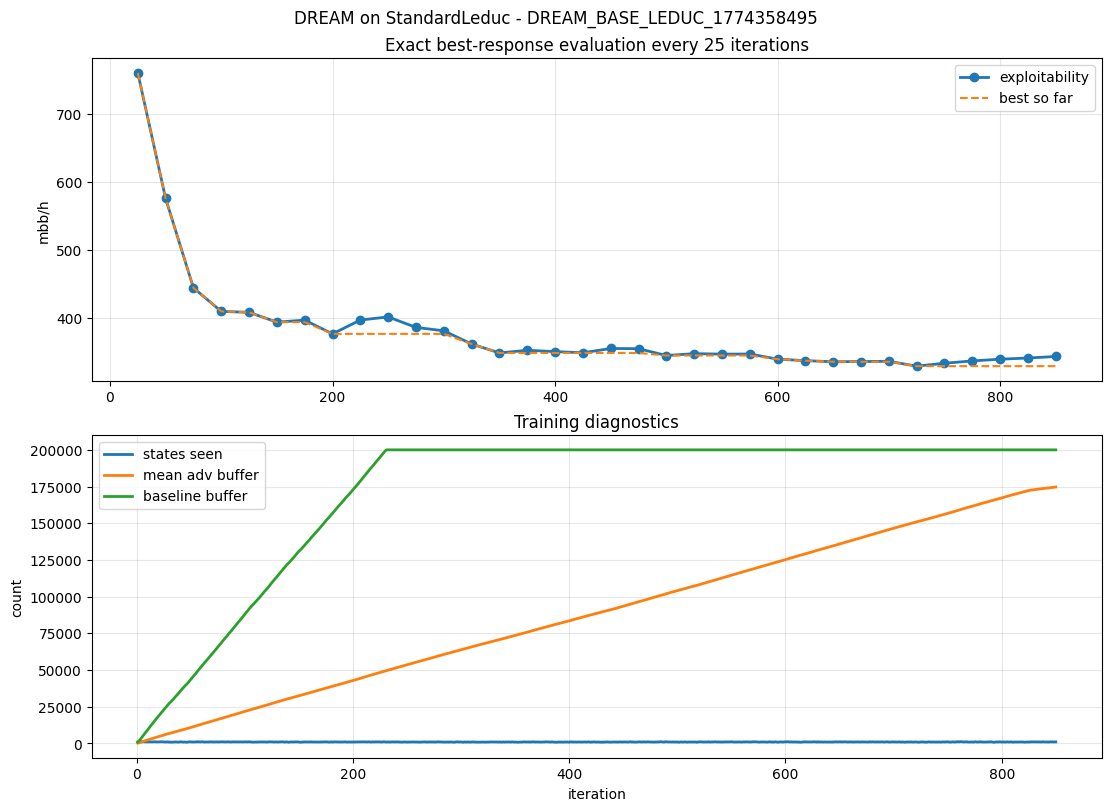

DREAM training:  85%|██████████████████▋   | 850/1000 [2:32:47<4:28:25, 107.37s/iter, states=1012, adv=174691, baseline=2e+5, expl=342.6452]

Run: DREAM_BASE_LEDUC_1774358495
Latest iteration 850: states_seen=1012 adv_bufs=[200000, 149383] baseline_buf=200000
Exploitability: first=760.6496 last=342.6452 delta=-418.0043
Recent evaluations:
  iter 750: exploitability=332.6933
  iter 775: exploitability=336.1199
  iter 800: exploitability=338.6427
  iter 825: exploitability=340.4126
  iter 850: exploitability=342.6452


DREAM training:  86%|███████████████████████████████████      | 856/1000 [2:33:08<37:52, 15.78s/iter, states=962, adv=175195, baseline=2e+5]

In [ ]:
RUN_NAME = None
ITERATIONS = 1_000
EVAL_EVERY = 25
TRAVERSALS = 100
ADV_BATCHES = 40
BASELINE_BATCHES = 20
BATCH_SIZE = 512
OS_EPS = 0.5
SEED = 12
TRAINING_DEVICE = "cpu"
PARAMETER_SERVER_DEVICE = "cpu"
INFERENCE_DEVICE = "cpu"


def build_run_name(run_name):
    if run_name is not None:
        return run_name
    return f"DREAM_BASE_LEDUC_{int(time.time())}"


set_seed(SEED)
DATA_ROOT.mkdir(parents=True, exist_ok=True)

run_name = build_run_name(RUN_NAME)
profile = TrainingProfile(
    name=run_name,
    path_data=str(DATA_ROOT),
    device_inference=INFERENCE_DEVICE,
    device_training=TRAINING_DEVICE,
    device_parameter_server=PARAMETER_SERVER_DEVICE,
    n_traversals_per_iter=TRAVERSALS,
    n_batches_adv_training=ADV_BATCHES,
    n_batches_per_iter_baseline=BASELINE_BATCHES,
    batch_size=BATCH_SIZE,
    os_eps=OS_EPS,
)

print("Running minimal standalone DREAM on StandardLeduc")
trainer = DreamTrainer(profile)
evaluator = ExploitabilityEvaluator(profile)
reports = trainer.run(
    n_iterations=ITERATIONS,
    eval_every=EVAL_EVERY,
    evaluator=evaluator,
    run_name=run_name,
)
out_dir = trainer.save_artifacts(run_name=run_name, reports=reports)

print("\nArtifacts")
print(f"- run: {run_name}")
print(f"- output: {out_dir}")
print(f"- latest report: {reports[-1] if reports else {}}")